# **Proyek Akhir: Membangun Sistem Machine Learning**
# **Telco Customer Churn Prediction**

**Author**: Eko Muhammad Rizki  
**Project**: SMSML_Eko_Muhammad_Rizki  
**Dataset**: [Telco Customer Churn - Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

# **1. Perkenalan Dataset**

## Telco Customer Churn Dataset

**Sumber Dataset**: [Kaggle - Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

**Deskripsi**:
Dataset ini berisi informasi pelanggan perusahaan telekomunikasi yang digunakan untuk memprediksi apakah seorang pelanggan akan berhenti berlangganan (churn) atau tidak.

**Karakteristik Dataset**:
- **Jumlah Baris**: 7.043 pelanggan
- **Jumlah Kolom**: 21 fitur
- **Target Variable**: `Churn` (Yes/No — Binary Classification)
- **Tipe Data**: Campuran (Numerik & Kategorikal)

**Fitur-fitur Utama**:
| Fitur | Deskripsi | Tipe |
|---|---|---|
| customerID | ID unik pelanggan | String |
| gender | Jenis kelamin | Kategorikal |
| SeniorCitizen | Apakah warga senior (0/1) | Numerik |
| Partner | Memiliki pasangan | Kategorikal |
| Dependents | Memiliki tanggungan | Kategorikal |
| tenure | Lama berlangganan (bulan) | Numerik |
| PhoneService | Layanan telepon | Kategorikal |
| MultipleLines | Multiple lines | Kategorikal |
| InternetService | Jenis layanan internet | Kategorikal |
| OnlineSecurity | Keamanan online | Kategorikal |
| OnlineBackup | Backup online | Kategorikal |
| DeviceProtection | Proteksi perangkat | Kategorikal |
| TechSupport | Dukungan teknis | Kategorikal |
| StreamingTV | Streaming TV | Kategorikal |
| StreamingMovies | Streaming film | Kategorikal |
| Contract | Jenis kontrak | Kategorikal |
| PaperlessBilling | Tagihan tanpa kertas | Kategorikal |
| PaymentMethod | Metode pembayaran | Kategorikal |
| MonthlyCharges | Biaya bulanan | Numerik |
| TotalCharges | Total biaya | Numerik |
| Churn | Target (Yes/No) | Kategorikal |

**Tujuan**: Membangun model machine learning untuk memprediksi customer churn, sehingga perusahaan dapat mengambil tindakan preventif untuk mempertahankan pelanggan.

**Author**: Eko Muhammad Rizki  
**Project**: SMSML_Eko_Muhammad_Rizki

# **2. Import Library**

Pada tahap ini, kita mengimpor semua pustaka (library) Python yang dibutuhkan untuk analisis data, visualisasi, preprocessing, dan pembangunan model machine learning.

In [1]:
# Install dependencies (jika di Google Colab)
# !pip install pandas numpy scikit-learn matplotlib seaborn mlflow

# === Data Manipulation ===
import pandas as pd
import numpy as np

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Preprocessing ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# === Models ===
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# === Evaluation ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

# === MLflow ===
import mlflow
import mlflow.sklearn

# === Utilities ===
import os
import json
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# === Display settings ===
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'MLflow version: {mlflow.__version__}')

All libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.4.4
MLflow version: 3.14.0


# **3. Memuat Dataset**

Pada tahap ini, kita memuat dataset Telco Customer Churn dari URL publik IBM Watson. Dataset dalam format CSV dan langsung dibaca menggunakan pandas.

In [2]:
# === Load Dataset ===
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print(f'Dataset berhasil dimuat!')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print(f'\nNama Kolom:')
print(list(df.columns))

Dataset berhasil dimuat!
Jumlah baris: 7043
Jumlah kolom: 21

Nama Kolom:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
# === Menampilkan 5 baris pertama ===
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# === Informasi Dataset ===
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# === Statistik Deskriptif ===
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [6]:
# === Cek Missing Values ===
print('Missing values per kolom:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per kolom:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values: 0


In [7]:
# === Cek data unik dan tipe ===
for col in df.columns:
    print(f'{col}: {df[col].dtype} — {df[col].nunique()} unique values')
    if df[col].dtype == 'object' and df[col].nunique() < 10:
        print(f'  Values: {df[col].value_counts().to_dict()}')

customerID: object — 7043 unique values
gender: object — 2 unique values
  Values: {'Male': 3555, 'Female': 3488}
SeniorCitizen: int64 — 2 unique values
Partner: object — 2 unique values
  Values: {'No': 3641, 'Yes': 3402}
Dependents: object — 2 unique values
  Values: {'No': 4933, 'Yes': 2110}
tenure: int64 — 73 unique values
PhoneService: object — 2 unique values
  Values: {'Yes': 6361, 'No': 682}
MultipleLines: object — 3 unique values
  Values: {'No': 3390, 'Yes': 2971, 'No phone service': 682}
InternetService: object — 3 unique values
  Values: {'Fiber optic': 3096, 'DSL': 2421, 'No': 1526}
OnlineSecurity: object — 3 unique values
  Values: {'No': 3498, 'Yes': 2019, 'No internet service': 1526}
OnlineBackup: object — 3 unique values
  Values: {'No': 3088, 'Yes': 2429, 'No internet service': 1526}
DeviceProtection: object — 3 unique values
  Values: {'No': 3095, 'Yes': 2422, 'No internet service': 1526}
TechSupport: object — 3 unique values
  Values: {'No': 3473, 'Yes': 2044, 'No i

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

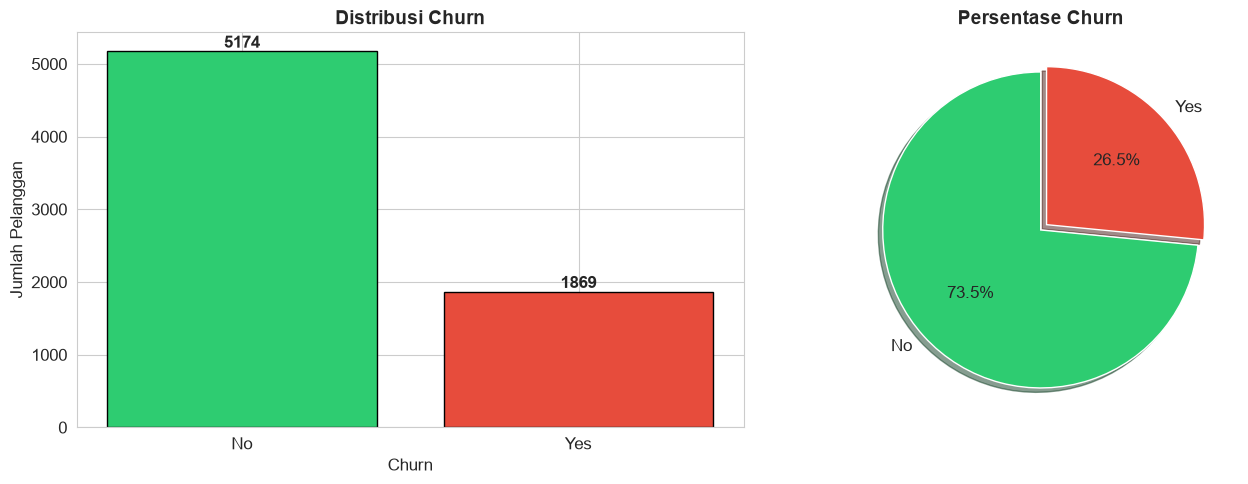

Churn ratio: {'No': 0.7346301292063041, 'Yes': 0.2653698707936959}


In [8]:
# === 4.1 Distribusi Target Variable (Churn) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribusi Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Jumlah Pelanggan')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0, 0.05],
            shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Persentase Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Churn ratio: {df["Churn"].value_counts(normalize=True).to_dict()}')

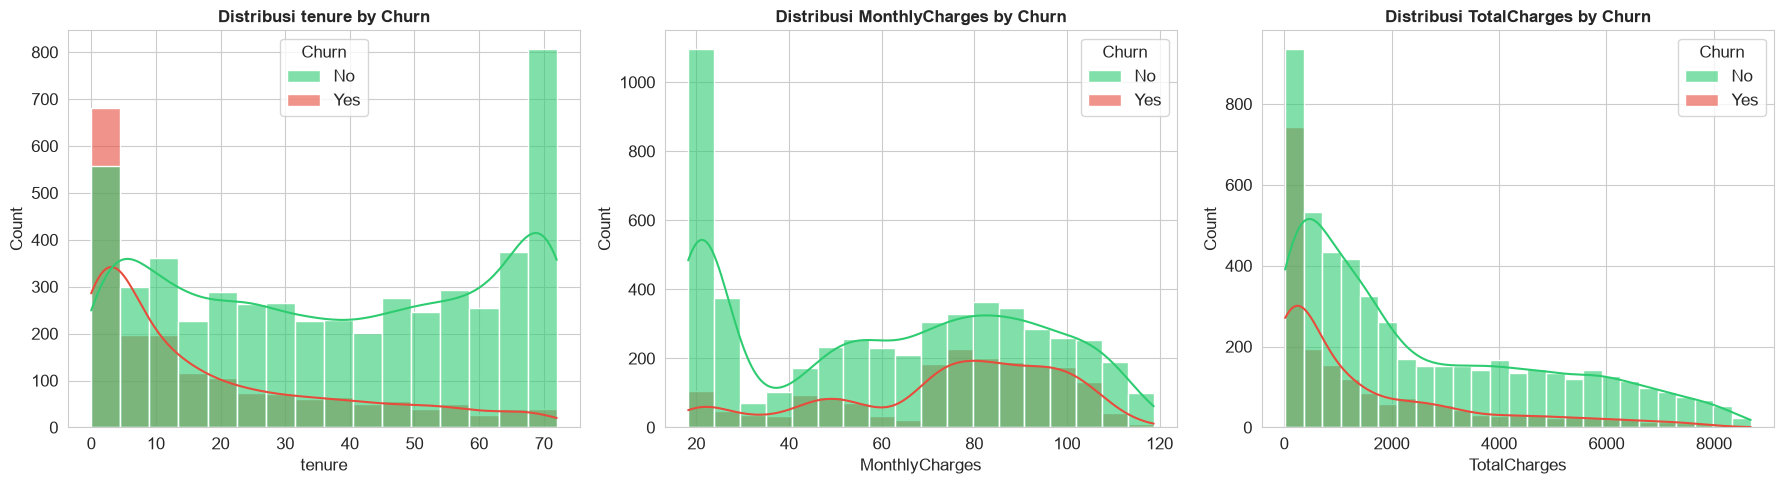

In [9]:
# === 4.2 Distribusi Fitur Numerik ===
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[idx],
                 palette=['#2ecc71', '#e74c3c'], alpha=0.6)
    axes[idx].set_title(f'Distribusi {col} by Churn', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)

plt.tight_layout()
plt.show()

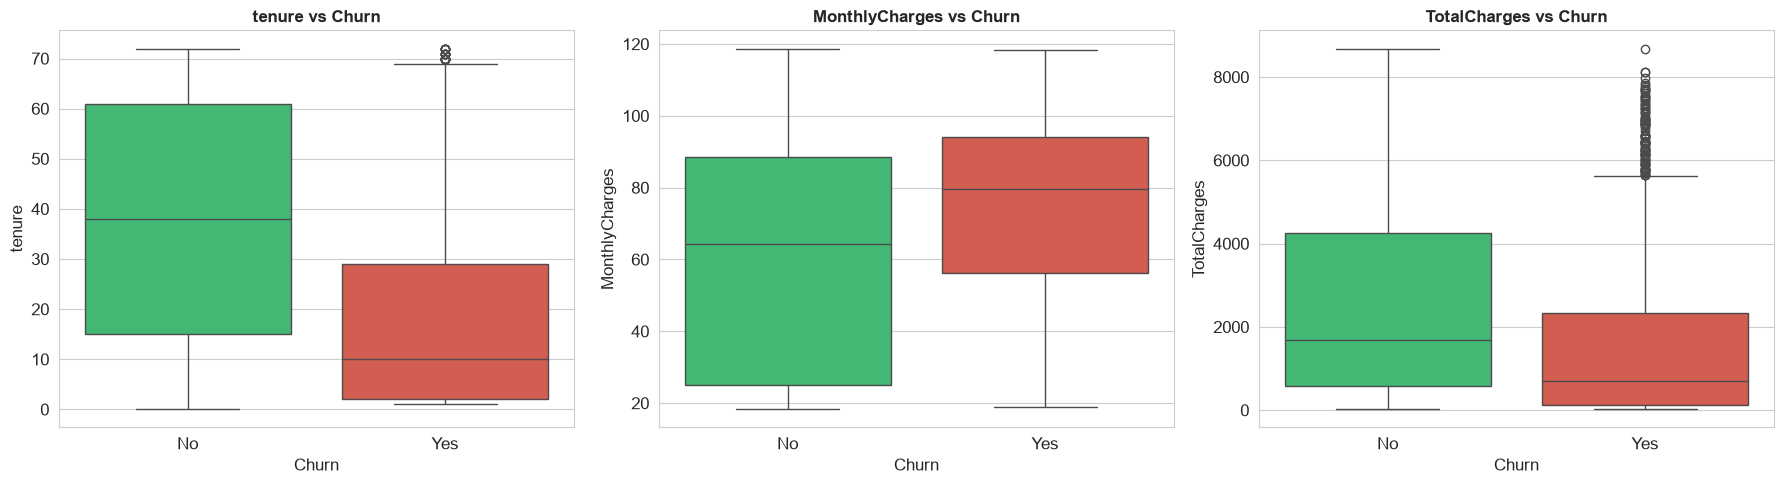

In [10]:
# === 4.3 Boxplot Fitur Numerik ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[idx],
                palette=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

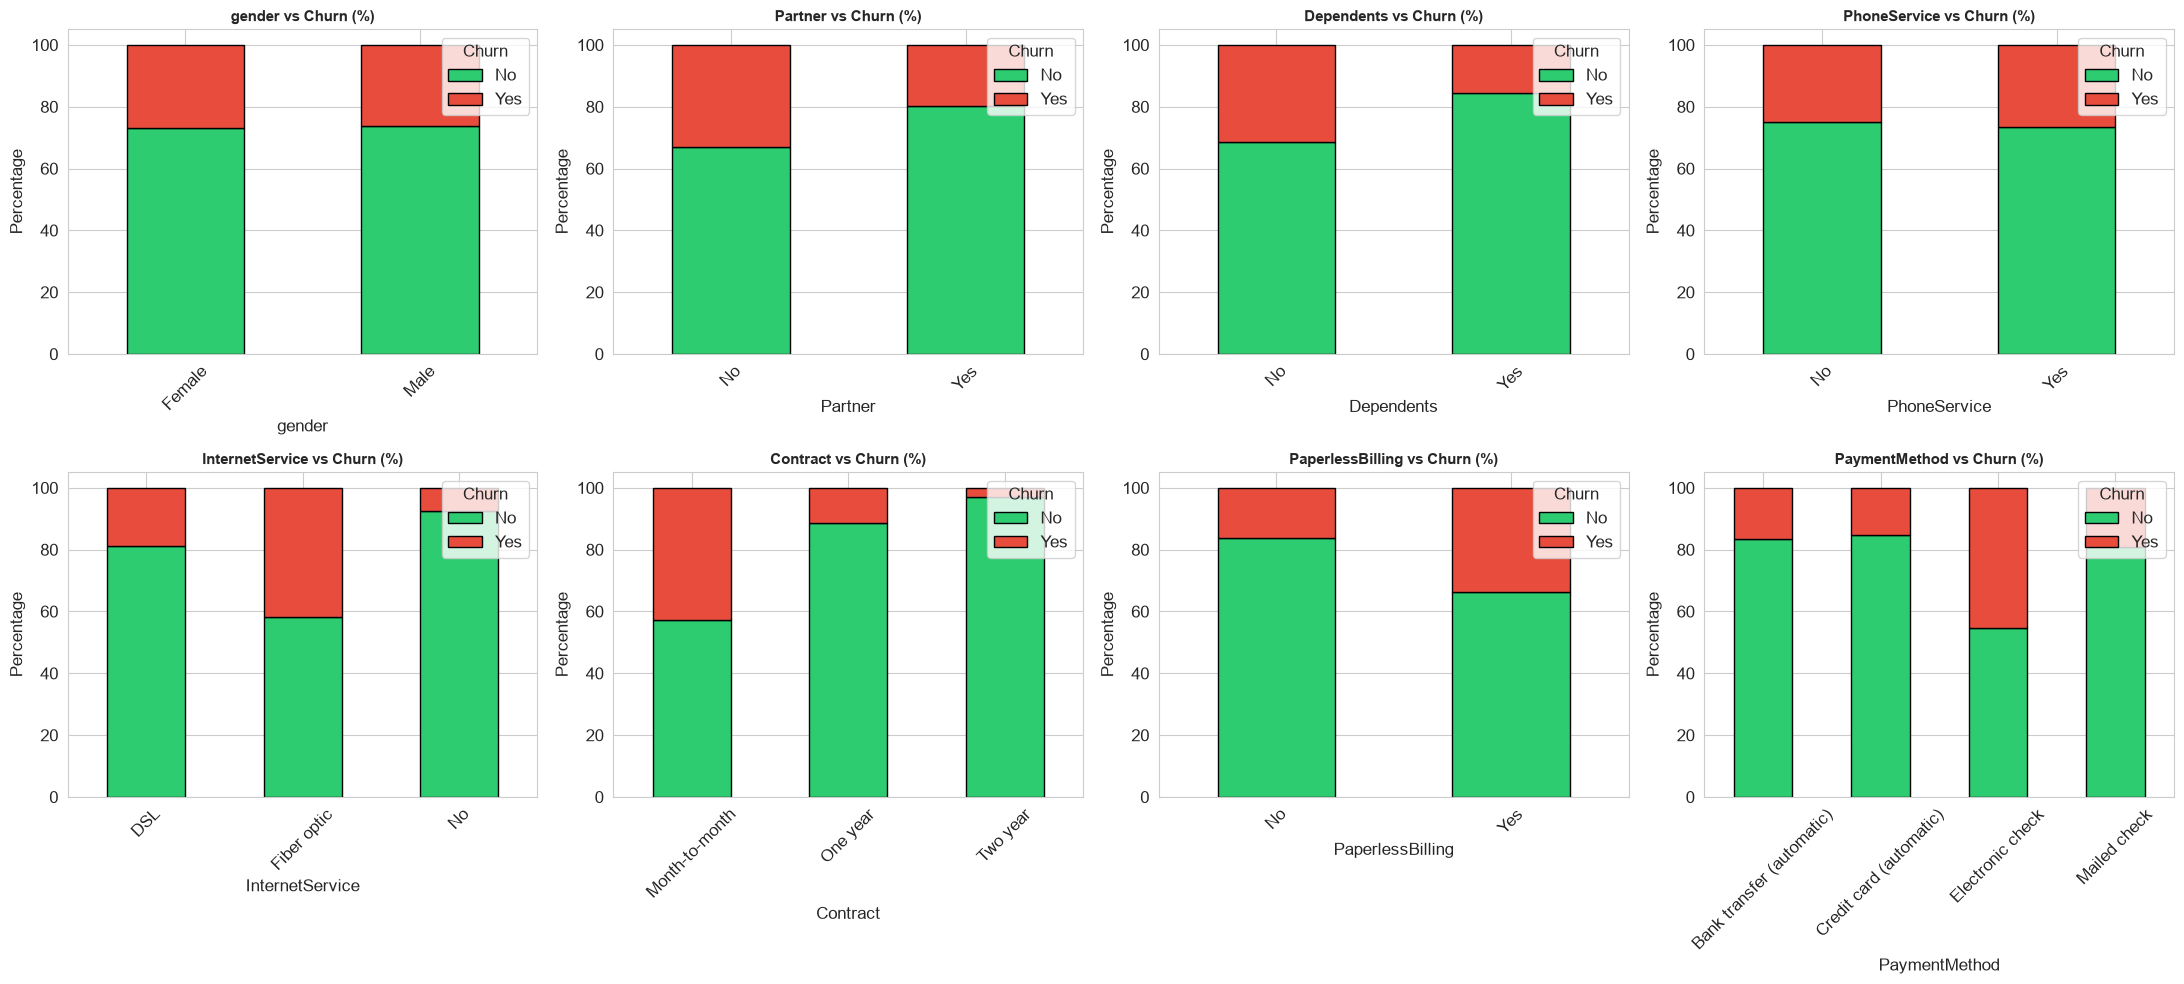

In [11]:
# === 4.4 Distribusi Fitur Kategorikal ===
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[idx],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[idx].set_title(f'{col} vs Churn (%)', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Percentage')
    axes[idx].legend(title='Churn', loc='upper right')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

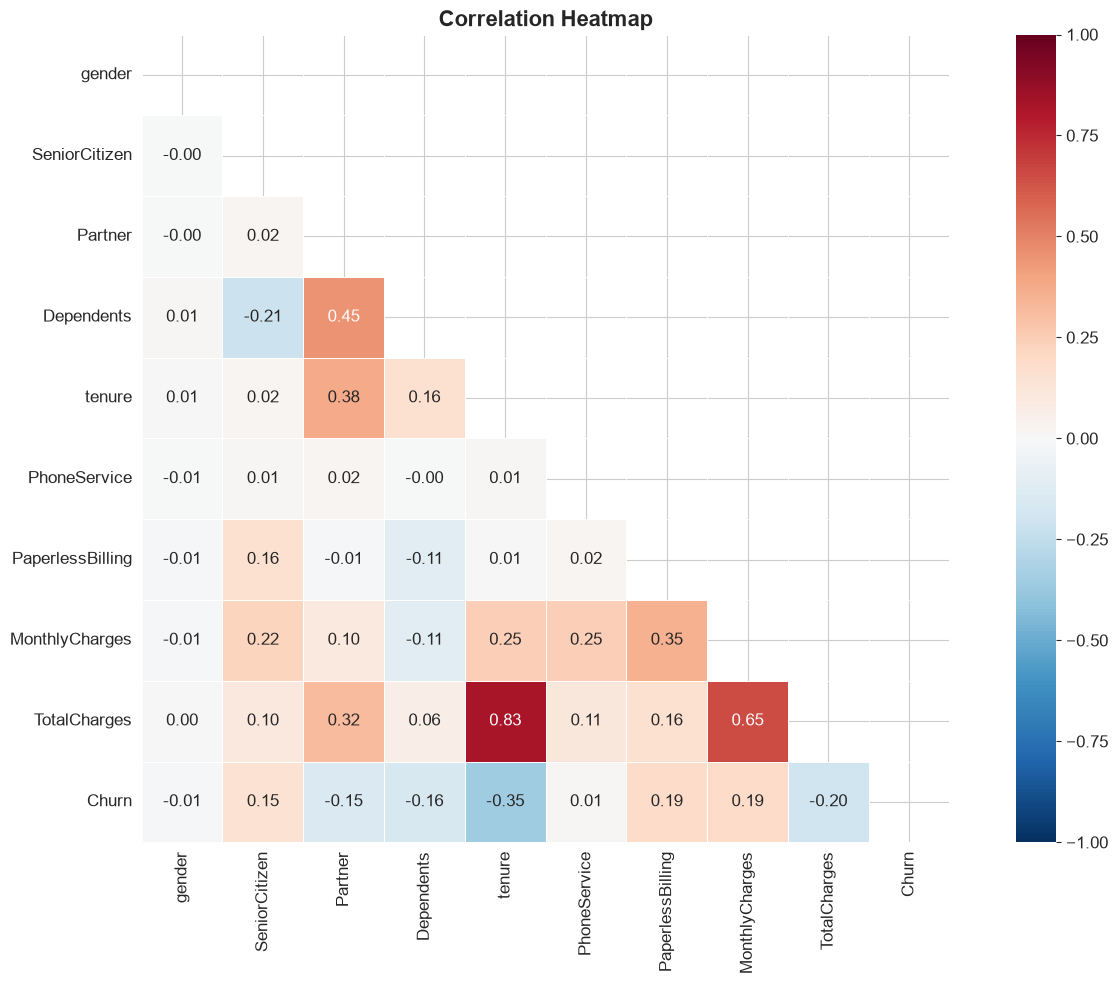


Korelasi dengan Churn:
Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PhoneService        0.011942
gender             -0.008612
Partner            -0.150448
Dependents         -0.164221
TotalCharges       -0.199484
tenure             -0.352229
Name: Churn, dtype: float64


In [12]:
# === 4.5 Correlation Heatmap ===
# Encode for correlation analysis
df_encoded = df.copy()
df_encoded['TotalCharges'] = pd.to_numeric(df_encoded['TotalCharges'], errors='coerce')

# Label encode binary columns for correlation
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Select only numeric columns
numeric_df = df_encoded.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
correlation = numeric_df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            square=True, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlation with target
print('\nKorelasi dengan Churn:')
churn_corr = correlation['Churn'].sort_values(ascending=False)
print(churn_corr)

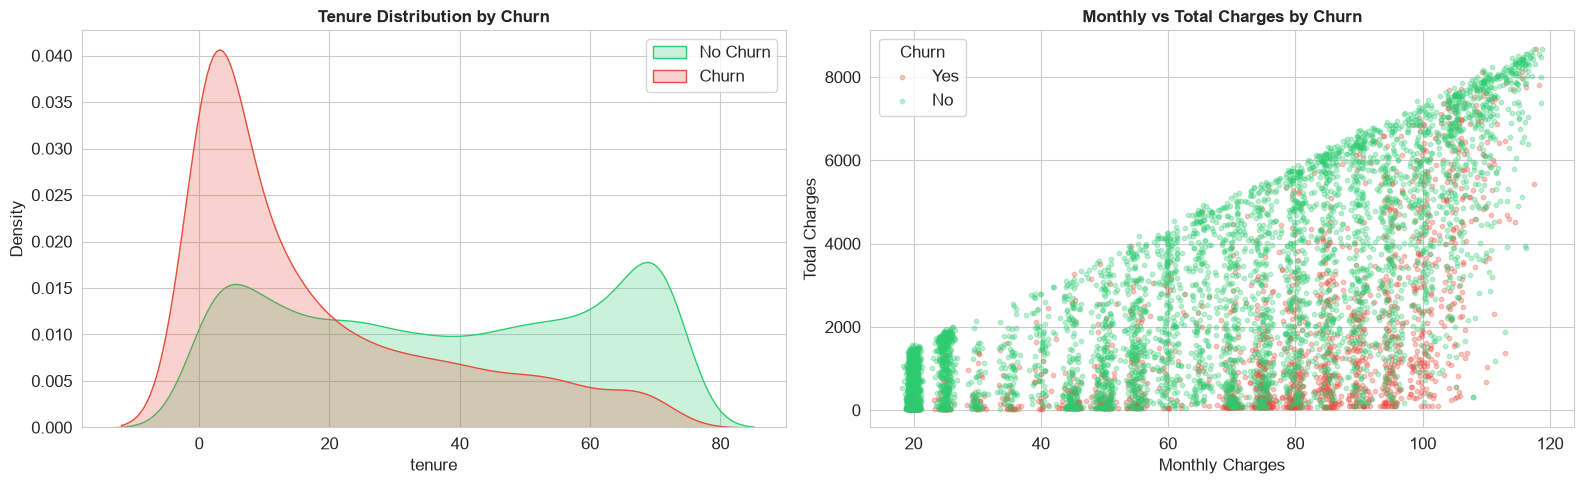

In [13]:
# === 4.6 Tenure vs Churn Analysis ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Tenure distribution by churn
sns.kdeplot(data=df[df['Churn'] == 'No'], x='tenure', ax=axes[0],
            fill=True, color='#2ecc71', label='No Churn')
sns.kdeplot(data=df[df['Churn'] == 'Yes'], x='tenure', ax=axes[0],
            fill=True, color='#e74c3c', label='Churn')
axes[0].set_title('Tenure Distribution by Churn', fontsize=12, fontweight='bold')
axes[0].legend()

# Monthly Charges vs Total Charges scatter
scatter_data = df.dropna(subset=['TotalCharges'])
colors_map = {'Yes': '#e74c3c', 'No': '#2ecc71'}
for label, color in colors_map.items():
    mask = scatter_data['Churn'] == label
    axes[1].scatter(scatter_data[mask]['MonthlyCharges'],
                    scatter_data[mask]['TotalCharges'],
                    c=color, alpha=0.3, label=label, s=10)
axes[1].set_title('Monthly vs Total Charges by Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monthly Charges')
axes[1].set_ylabel('Total Charges')
axes[1].legend(title='Churn')

plt.tight_layout()
plt.show()

In [14]:
# === 4.7 Ringkasan EDA ===
print('='*60)
print('RINGKASAN EDA - TELCO CUSTOMER CHURN')
print('='*60)
print(f'\n1. Dataset memiliki {df.shape[0]} baris dan {df.shape[1]} kolom')
print(f'2. Target variable (Churn) tidak seimbang:')
print(f'   - No Churn: {(df["Churn"]=="No").sum()} ({(df["Churn"]=="No").mean()*100:.1f}%)')
print(f'   - Churn: {(df["Churn"]=="Yes").sum()} ({(df["Churn"]=="Yes").mean()*100:.1f}%)')
print(f'3. TotalCharges memiliki {df["TotalCharges"].isna().sum()} missing values')
print(f'4. Pelanggan dengan tenure pendek cenderung churn')
print(f'5. Contract month-to-month memiliki churn rate tertinggi')
print(f'6. Pelanggan dengan MonthlyCharges tinggi cenderung churn')
print(f'7. Fiber optic memiliki churn rate lebih tinggi dari DSL')

RINGKASAN EDA - TELCO CUSTOMER CHURN

1. Dataset memiliki 7043 baris dan 21 kolom
2. Target variable (Churn) tidak seimbang:
   - No Churn: 5174 (73.5%)
   - Churn: 1869 (26.5%)
3. TotalCharges memiliki 11 missing values
4. Pelanggan dengan tenure pendek cenderung churn
5. Contract month-to-month memiliki churn rate tertinggi
6. Pelanggan dengan MonthlyCharges tinggi cenderung churn
7. Fiber optic memiliki churn rate lebih tinggi dari DSL


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Tahapan yang dilakukan:
1. Menghapus kolom yang tidak relevan (customerID)
2. Menangani missing values (TotalCharges)
3. Menghapus data duplikat
4. Feature Engineering (tenure_group, charge_ratio, dll)
5. Encoding data kategorikal (LabelEncoder + OneHotEncoder)
6. Train/Test Split (80/20 stratified)
7. Normalisasi fitur numerik (StandardScaler)

In [15]:
# === 5.1 Hapus Kolom Tidak Relevan ===
df_clean = df.copy()

# Drop customerID
df_clean = df_clean.drop(columns=['customerID'])
print(f'Kolom customerID dihapus. Remaining: {df_clean.shape[1]} kolom')

Kolom customerID dihapus. Remaining: 20 kolom


In [16]:
# === 5.2 Handle Missing Values ===
# TotalCharges: convert to numeric, fill NaN with median
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

missing_count = df_clean['TotalCharges'].isna().sum()
print(f'Missing values di TotalCharges: {missing_count}')

median_total = df_clean['TotalCharges'].median()
df_clean['TotalCharges'].fillna(median_total, inplace=True)
print(f'Filled with median: {median_total:.2f}')
print(f'Remaining missing: {df_clean.isnull().sum().sum()}')

Missing values di TotalCharges: 11
Filled with median: 1397.47
Remaining missing: 0


In [17]:
# === 5.3 Hapus Duplikat ===
duplicates = df_clean.duplicated().sum()
print(f'Jumlah duplikat: {duplicates}')
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'Duplikat dihapus. Remaining: {df_clean.shape[0]} baris')

Jumlah duplikat: 22
Duplikat dihapus. Remaining: 7021 baris


In [18]:
# === 5.4 Feature Engineering ===

# Tenure groups
bins = [0, 12, 24, 48, 60, np.inf]
labels = ['0-12', '13-24', '25-48', '49-60', '61+']
df_clean['tenure_group'] = pd.cut(df_clean['tenure'], bins=bins, labels=labels)

# Charge per month ratio
df_clean['charge_per_month_ratio'] = df_clean['TotalCharges'] / (df_clean['tenure'] + 1)

# Is new customer
df_clean['is_new_customer'] = (df_clean['tenure'] <= 6).astype(int)

# Internet add-on count
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
df_clean['has_internet_addon'] = df_clean[addon_cols].apply(
    lambda row: sum(1 for val in row if val == 'Yes'), axis=1
)

# Monthly charge category
charge_bins = [0, 30, 60, 90, np.inf]
charge_labels = ['Low', 'Medium', 'High', 'Very High']
df_clean['monthly_charge_category'] = pd.cut(
    df_clean['MonthlyCharges'], bins=charge_bins, labels=charge_labels
)

print('Feature Engineering selesai!')
print(f'Fitur baru: tenure_group, charge_per_month_ratio, is_new_customer, has_internet_addon, monthly_charge_category')
print(f'Total kolom sekarang: {df_clean.shape[1]}')

Feature Engineering selesai!
Fitur baru: tenure_group, charge_per_month_ratio, is_new_customer, has_internet_addon, monthly_charge_category
Total kolom sekarang: 25


In [19]:
# === 5.5 Encoding Kategorikal ===

# Label Encoding untuk kolom binary
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    encoders[col] = le
    print(f'Label Encoded: {col}')

# One-Hot Encoding untuk multi-category columns
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                  'OnlineBackup', 'DeviceProtection', 'TechSupport',
                  'StreamingTV', 'StreamingMovies', 'Contract',
                  'PaymentMethod', 'tenure_group', 'monthly_charge_category']

df_clean = pd.get_dummies(df_clean, columns=multi_cat_cols, drop_first=True, dtype=int)
print(f'\nOne-Hot Encoding selesai!')
print(f'Total fitur setelah encoding: {df_clean.shape[1]}')


Label Encoded: gender
Label Encoded: Partner
Label Encoded: Dependents
Label Encoded: PhoneService
Label Encoded: PaperlessBilling
Label Encoded: Churn

One-Hot Encoding selesai!
Total fitur setelah encoding: 41


In [20]:
# === 5.6 Train/Test Split ===
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'Features: {X_train.shape[1]}')
print(f'Churn ratio - Train: {y_train.mean():.3f}, Test: {y_test.mean():.3f}')

Training set: 5616 samples
Test set: 1405 samples
Features: 40
Churn ratio - Train: 0.264, Test: 0.265


In [21]:
# === 5.7 Normalisasi/Scaling ===
numerical_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charge_per_month_ratio']

scaler = StandardScaler()
X_train[numerical_to_scale] = scaler.fit_transform(X_train[numerical_to_scale])
X_test[numerical_to_scale] = scaler.transform(X_test[numerical_to_scale])

print('StandardScaler applied!')
print(f'\nScaled columns: {numerical_to_scale}')
print(f'\nX_train sample (first 5 rows):')
X_train.head()

StandardScaler applied!

Scaled columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'charge_per_month_ratio']

X_train sample (first 5 rows):


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,charge_per_month_ratio,is_new_customer,has_internet_addon,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24,tenure_group_25-48,tenure_group_49-60,tenure_group_61+,monthly_charge_category_Medium,monthly_charge_category_High,monthly_charge_category_Very High
2629,1,0,0,0,-1.241331,1,0,0.193165,-0.946351,-0.235476,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
2650,0,0,0,0,-0.711078,1,1,0.647355,-0.435346,0.325140,0,2,0,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0
1418,1,0,1,1,1.409933,1,1,0.820380,1.794547,0.525027,0,2,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0
5774,1,0,0,0,-1.118965,1,1,0.023467,-0.858746,-0.077113,1,3,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
2425,1,0,0,0,-0.262403,1,1,-1.483847,-0.783389,-0.689692,0,0,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0


In [22]:
# === 5.8 Ringkasan Preprocessing ===
print('='*60)
print('RINGKASAN PREPROCESSING')
print('='*60)
print(f'\n1. Kolom customerID dihapus')
print(f'2. {missing_count} missing values di TotalCharges diisi dengan median')
print(f'3. {duplicates} duplikat ditemukan')
print(f'4. 5 fitur baru dibuat (feature engineering)')
print(f'5. Binary columns: Label Encoded')
print(f'6. Multi-category columns: One-Hot Encoded')
print(f'7. Train/Test split: 80/20 (stratified)')
print(f'8. Numerical columns: StandardScaler applied')
print(f'\nFinal dataset shape:')
print(f'  X_train: {X_train.shape}')
print(f'  X_test: {X_test.shape}')
print(f'  y_train: {y_train.shape}')
print(f'  y_test: {y_test.shape}')
print(f'\nFeature names ({len(X_train.columns)}):')
for i, col in enumerate(X_train.columns, 1):
    print(f'  {i}. {col}')

RINGKASAN PREPROCESSING

1. Kolom customerID dihapus
2. 11 missing values di TotalCharges diisi dengan median
3. 22 duplikat ditemukan
4. 5 fitur baru dibuat (feature engineering)
5. Binary columns: Label Encoded
6. Multi-category columns: One-Hot Encoded
7. Train/Test split: 80/20 (stratified)
8. Numerical columns: StandardScaler applied

Final dataset shape:
  X_train: (5616, 40)
  X_test: (1405, 40)
  y_train: (5616,)
  y_test: (1405,)

Feature names (40):
  1. gender
  2. SeniorCitizen
  3. Partner
  4. Dependents
  5. tenure
  6. PhoneService
  7. PaperlessBilling
  8. MonthlyCharges
  9. TotalCharges
  10. charge_per_month_ratio
  11. is_new_customer
  12. has_internet_addon
  13. MultipleLines_No phone service
  14. MultipleLines_Yes
  15. InternetService_Fiber optic
  16. InternetService_No
  17. OnlineSecurity_No internet service
  18. OnlineSecurity_Yes
  19. OnlineBackup_No internet service
  20. OnlineBackup_Yes
  21. DeviceProtection_No internet service
  22. DeviceProtect

In [ ]:
# === 5.9 Menyimpan Hasil Preprocessing ===
import os
import joblib
import json
from datetime import datetime

output_dir = 'namadataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Save processed datasets
X_train.to_csv(os.path.join(output_dir, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(output_dir, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(output_dir, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(output_dir, 'y_test.csv'), index=False)

# Save scaler and encoders artifacts
joblib.dump(scaler, os.path.join(output_dir, 'scaler.joblib'))
joblib.dump(encoders, os.path.join(output_dir, 'encoders.joblib'))

# Save feature names
feature_names = list(X_train.columns)
with open(os.path.join(output_dir, 'feature_names.json'), 'w') as f:
    json.dump(feature_names, f, indent=2)

# Save preprocessing summary
summary = {
    "timestamp": datetime.now().isoformat(),
    "raw_rows": len(df_clean) + duplicates if ('df_clean' in globals() and 'duplicates' in globals()) else 7043,
    "processed_features": len(feature_names),
    "train_samples": len(X_train),
    "test_samples": len(X_test),
    "churn_ratio_train": float(y_train.mean()),
    "churn_ratio_test": float(y_test.mean()),
    "feature_names": feature_names
}
with open(os.path.join(output_dir, 'preprocessing_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Dataset dan metadata preprocessing berhasil disimpan di folder '{output_dir}/'!")


# **6. Modelling dengan MLflow**

Pada tahap ini, kita membangun model machine learning menggunakan 3 algoritma baseline:
1. **Logistic Regression** — model linear untuk binary classification
2. **Random Forest** — ensemble learning berbasis decision tree
3. **Gradient Boosting** — ensemble learning dengan boosting technique

Setiap eksperimen dicatat menggunakan **MLflow** dengan:
- `mlflow.sklearn.autolog(log_models=True)` — otomatis mencatat parameters, metrics, dan model artifacts
- Manual logging — confusion_matrix.png, classification_report.json sebagai custom artifacts

In [23]:
# === 6.1 Setup MLflow ===
EXPERIMENT_NAME = 'telco-churn-baseline'

# Set tracking URI (local SQLite database)
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment(EXPERIMENT_NAME)

# Enable autolog — automatically logs parameters, metrics, and model artifacts
# log_models=True ensures the full model/ folder is created:
#   MLmodel, conda.yaml, model.pkl, python_env.yaml, requirements.txt, estimator.html
mlflow.sklearn.autolog(log_models=True)

print(f'MLflow sklearn.autolog enabled (log_models=True)')
print(f'Tracking URI: sqlite:///mlflow.db')
print(f'Experiment: {EXPERIMENT_NAME}')

MLflow sklearn.autolog enabled (log_models=True)
Tracking URI: sqlite:///mlflow.db
Experiment: telco-churn-baseline


In [24]:
# === 6.2 Definisi Model Baseline ===
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=42, solver='lbfgs', C=1.0
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_split=5,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        subsample=0.8, random_state=42
    )
}

print('Model baseline yang akan ditraining:')
for name, model in models.items():
    print(f'  - {name}: {model.__class__.__name__}')

Model baseline yang akan ditraining:
  - LogisticRegression: LogisticRegression
  - RandomForest: RandomForestClassifier
  - GradientBoosting: GradientBoostingClassifier


2026/07/13 11:06:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training: LogisticRegression


  accuracy: 0.8000
  precision: 0.6643
  recall: 0.4946
  f1_score: 0.5670
  auc_roc: 0.8427
  training_time: 4.38s


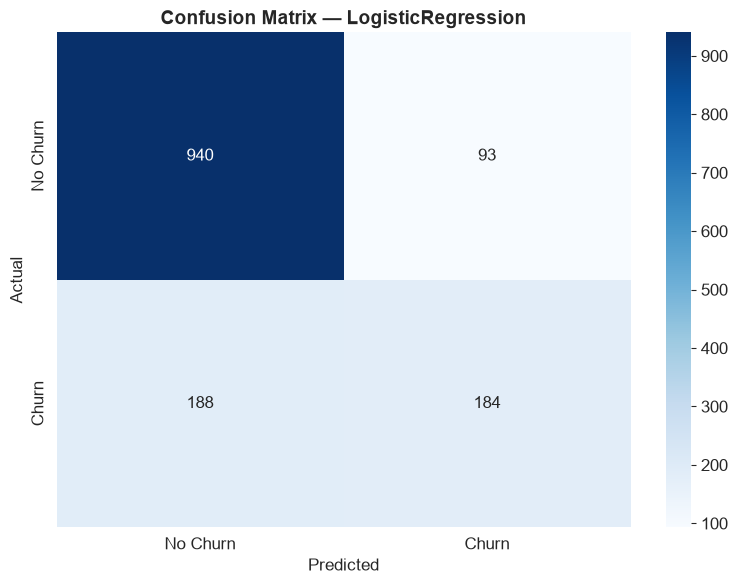


  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1033
       Churn       0.66      0.49      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.70      0.72      1405
weighted avg       0.79      0.80      0.79      1405

  MLflow Run ID: 3153a872f039436cbbc664d7686f036b

Training: RandomForest


2026/07/13 11:07:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  accuracy: 0.7922
  precision: 0.6429
  recall: 0.4839
  f1_score: 0.5521
  auc_roc: 0.8328
  training_time: 3.81s


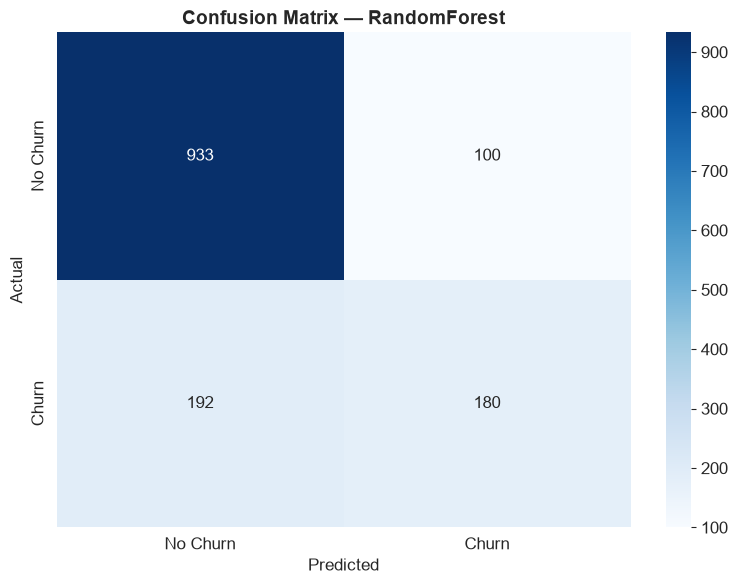


  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.64      0.48      0.55       372

    accuracy                           0.79      1405
   macro avg       0.74      0.69      0.71      1405
weighted avg       0.78      0.79      0.78      1405

  MLflow Run ID: 0e381c411ca54752be4e8ec16cda7e53

Training: GradientBoosting


2026/07/13 11:07:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  accuracy: 0.7872
  precision: 0.6237
  recall: 0.4946
  f1_score: 0.5517
  auc_roc: 0.8327
  training_time: 4.25s


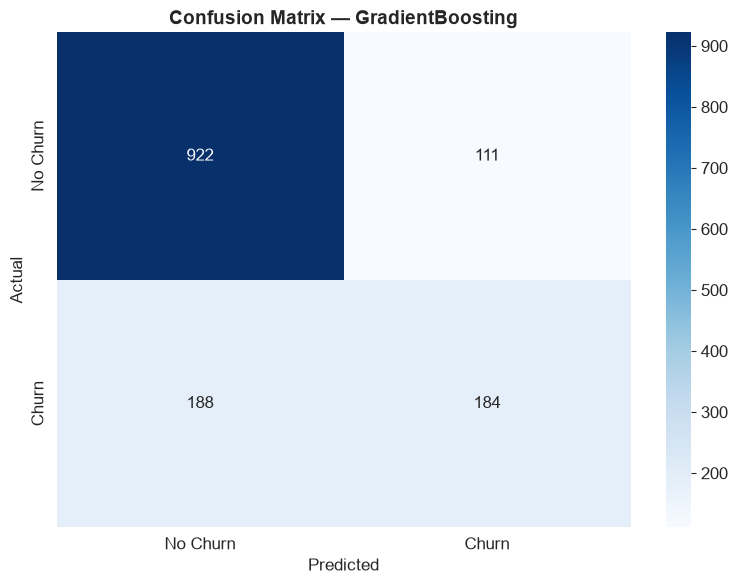


  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.49      0.55       372

    accuracy                           0.79      1405
   macro avg       0.73      0.69      0.71      1405
weighted avg       0.78      0.79      0.78      1405

  MLflow Run ID: de17f78a717045adad01b2b1e7df9ed1

All models trained and logged to MLflow!


In [25]:
# === 6.3 Training & MLflow Logging ===
results = []
roc_data = []

for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        print(f"\n{'='*60}")
        print(f'Training: {model_name}')
        print(f"{'='*60}")

        # Train model — autolog captures params, metrics, and model artifact
        start_time = datetime.now()
        model.fit(X_train, y_train)
        train_time = (datetime.now() - start_time).total_seconds()

        # Predict
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate metrics
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'auc_roc': roc_auc_score(y_test, y_pred_proba),
        }

        # Log additional metrics manually
        mlflow.log_metric('precision', metrics['precision'])
        mlflow.log_metric('recall', metrics['recall'])
        mlflow.log_metric('auc_roc', metrics['auc_roc'])
        mlflow.log_metric('training_time_seconds', train_time)

        # Print metrics
        for metric_name, metric_value in metrics.items():
            print(f'  {metric_name}: {metric_value:.4f}')
        print(f'  training_time: {train_time:.2f}s')

        # Custom Artifact 1: Confusion Matrix PNG
        cm = confusion_matrix(y_test, y_pred)
        fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['No Churn', 'Churn'],
                    yticklabels=['No Churn', 'Churn'], ax=ax_cm)
        ax_cm.set_title(f'Confusion Matrix — {model_name}', fontsize=14, fontweight='bold')
        ax_cm.set_ylabel('Actual', fontsize=12)
        ax_cm.set_xlabel('Predicted', fontsize=12)
        plt.tight_layout()

        os.makedirs(f'artifacts/{model_name}', exist_ok=True)
        cm_path = f'artifacts/{model_name}/confusion_matrix.png'
        fig_cm.savefig(cm_path, dpi=150, bbox_inches='tight')
        mlflow.log_artifact(cm_path, artifact_path='custom_artifacts')
        plt.show()

        # Custom Artifact 2: Classification Report JSON
        report = classification_report(y_test, y_pred,
                                       target_names=['No Churn', 'Churn'],
                                       output_dict=True)
        report['model_name'] = model_name
        report['timestamp'] = datetime.now().isoformat()
        cr_path = f'artifacts/{model_name}/classification_report.json'
        with open(cr_path, 'w') as f:
            json.dump(report, f, indent=2)
        mlflow.log_artifact(cr_path, artifact_path='custom_artifacts')

        # Classification report text
        print(f'\n  Classification Report:')
        print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

        run_id = mlflow.active_run().info.run_id
        print(f'  MLflow Run ID: {run_id}')

        results.append({
            'model_name': model_name,
            'run_id': run_id,
            'metrics': metrics,
            'training_time': train_time,
        })
        roc_data.append((model_name, y_test, y_pred_proba))

print(f"\n{'='*60}")
print('All models trained and logged to MLflow!')
print(f"{'='*60}")

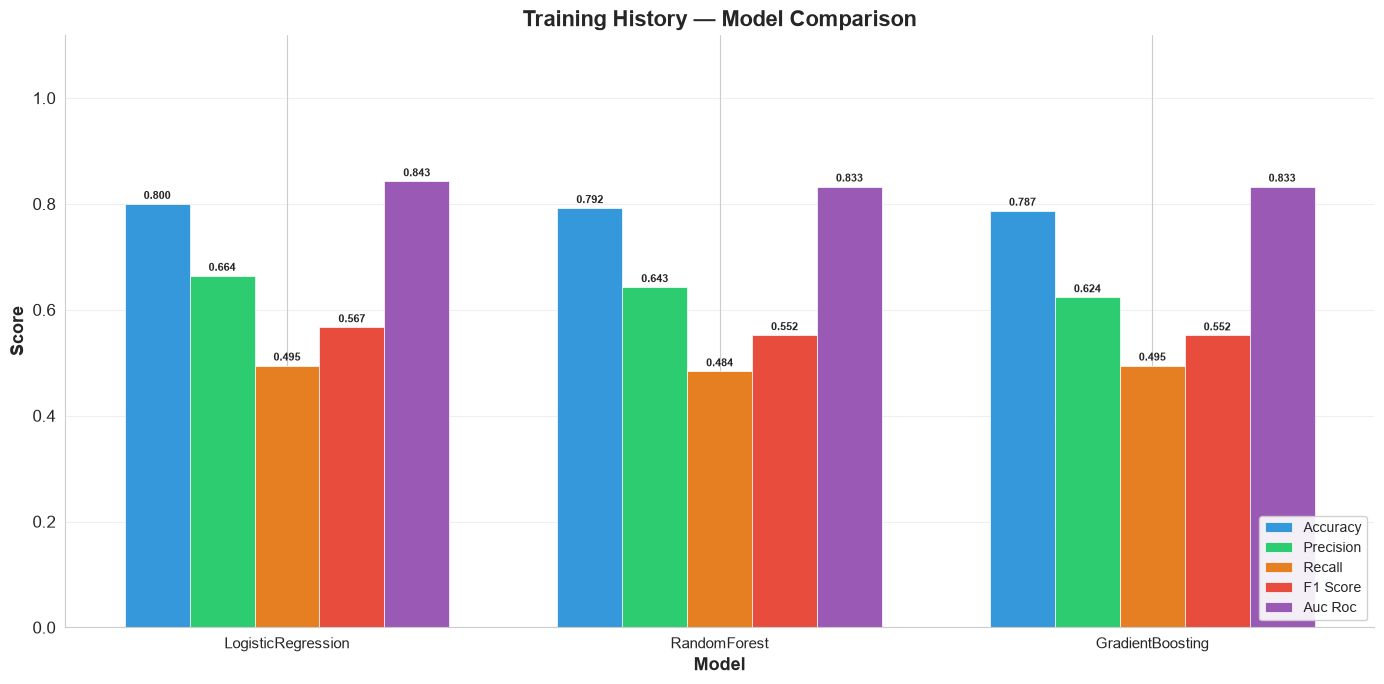

Training history saved to artifacts/training_history.png


In [26]:
# === 6.4 Training History — Model Comparison ===
model_names = [r['model_name'] for r in results]
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'auc_roc']
x = np.arange(len(model_names))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6']

for i, metric in enumerate(metrics_to_plot):
    values = [r['metrics'][metric] for r in results]
    bars = ax.bar(x + i * width, values, width,
                  label=metric.replace('_', ' ').title(),
                  color=colors[i], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Training History — Model Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_ylim(0, 1.12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save as artifact
os.makedirs('artifacts', exist_ok=True)
history_path = 'artifacts/training_history.png'
fig.savefig(history_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Training history saved to {history_path}')

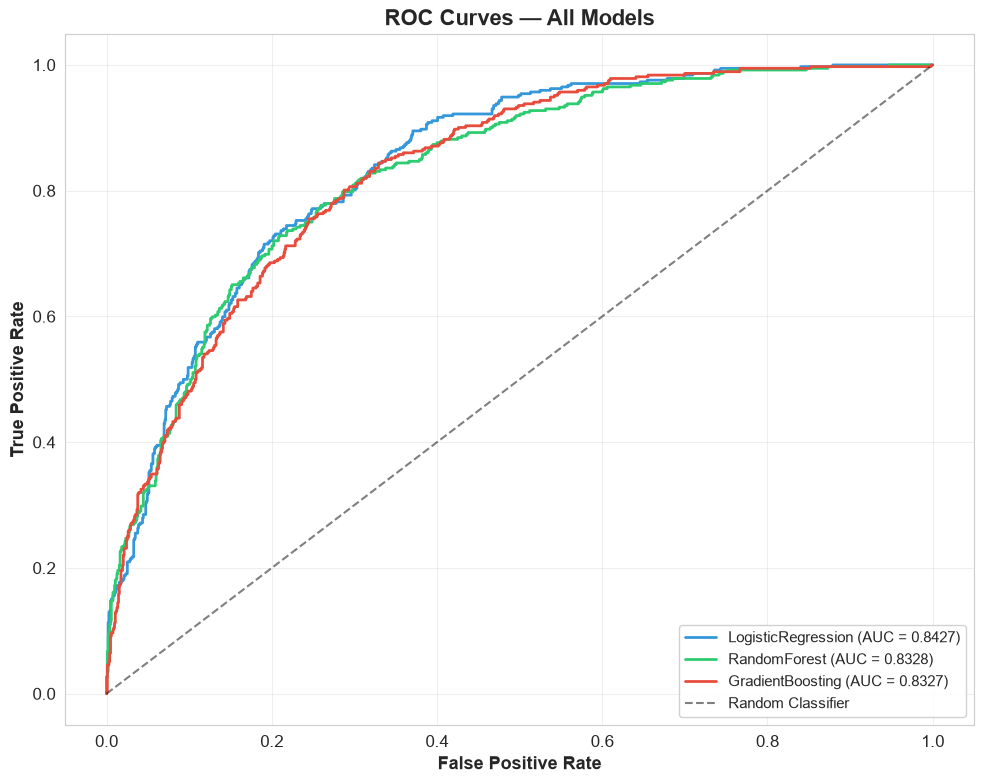

ROC curves saved to artifacts/roc_curves.png


In [27]:
# === 6.5 ROC Curves ===
fig, ax = plt.subplots(figsize=(10, 8))
roc_colors = ['#3498db', '#2ecc71', '#e74c3c']

for (model_name, y_true, y_proba), color in zip(roc_data, roc_colors):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{model_name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.set_title('ROC Curves — All Models', fontsize=16, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.grid(alpha=0.3)

plt.tight_layout()

roc_path = 'artifacts/roc_curves.png'
fig.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC curves saved to {roc_path}')

In [28]:
# === 6.6 Log Summary Artifacts to MLflow ===
with mlflow.start_run(run_name='Training_Summary'):
    mlflow.log_artifact('artifacts/training_history.png', artifact_path='summary')
    mlflow.log_artifact('artifacts/roc_curves.png', artifact_path='summary')

    best = max(results, key=lambda x: x['metrics']['f1_score'])
    mlflow.log_param('best_model', best['model_name'])
    mlflow.log_metric('best_f1_score', best['metrics']['f1_score'])
    mlflow.log_metric('best_auc_roc', best['metrics']['auc_roc'])

    print('Training history and ROC curves logged as summary artifacts')

Training history and ROC curves logged as summary artifacts


In [29]:
# === 6.7 Hasil Akhir — Tabel Perbandingan Model ===
print('='*60)
print('BASELINE RESULTS SUMMARY')
print('='*60)

summary_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Accuracy': f"{r['metrics']['accuracy']:.4f}",
        'Precision': f"{r['metrics']['precision']:.4f}",
        'Recall': f"{r['metrics']['recall']:.4f}",
        'F1-Score': f"{r['metrics']['f1_score']:.4f}",
        'AUC-ROC': f"{r['metrics']['auc_roc']:.4f}",
        'Training Time (s)': f"{r['training_time']:.2f}",
        'MLflow Run ID': r['run_id']
    }
    for r in results
])

print(summary_df.to_string(index=False))

best = max(results, key=lambda x: x['metrics']['f1_score'])
print(f"\n🏆 Best Model: {best['model_name']}")
print(f"   F1-Score: {best['metrics']['f1_score']:.4f}")
print(f"   AUC-ROC: {best['metrics']['auc_roc']:.4f}")
print(f"   MLflow Run ID: {best['run_id']}")

BASELINE RESULTS SUMMARY
             Model Accuracy Precision Recall F1-Score AUC-ROC Training Time (s)                    MLflow Run ID
LogisticRegression   0.8000    0.6643 0.4946   0.5670  0.8427              4.38 3153a872f039436cbbc664d7686f036b
      RandomForest   0.7922    0.6429 0.4839   0.5521  0.8328              3.81 0e381c411ca54752be4e8ec16cda7e53
  GradientBoosting   0.7872    0.6237 0.4946   0.5517  0.8327              4.25 de17f78a717045adad01b2b1e7df9ed1

🏆 Best Model: LogisticRegression
   F1-Score: 0.5670
   AUC-ROC: 0.8427
   MLflow Run ID: 3153a872f039436cbbc664d7686f036b


# **7. Kesimpulan**

Dari eksperimen yang telah dilakukan, berikut adalah kesimpulan:

1. **Dataset** Telco Customer Churn memiliki 7.043 sampel dengan 21 fitur. Target variable tidak seimbang (73.5% No Churn vs 26.5% Churn).

2. **Preprocessing** yang dilakukan meliputi:
   - Penanganan missing values pada TotalCharges
   - Feature engineering (5 fitur baru)
   - Label encoding untuk fitur binary dan one-hot encoding untuk fitur multi-kategori
   - StandardScaler untuk normalisasi fitur numerik

3. **Model Baseline** yang dibangun:
   - Logistic Regression
   - Random Forest
   - Gradient Boosting

4. **MLflow Tracking** digunakan untuk mencatat seluruh eksperimen:
   - `mlflow.sklearn.autolog(log_models=True)` mencatat parameter, metrik, dan model artifact secara otomatis
   - Custom artifacts: confusion_matrix.png, classification_report.json, training_history.png

5. Semua eksperimen dapat dibandingkan melalui MLflow UI dengan menjalankan `mlflow ui` dan membuka browser di `http://localhost:5000`.